In [1]:
import os
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
from ast import literal_eval
import re
import json

In [2]:
def getArrFromCsv(data):
    
    if(data is None):
        return []
    
    return [r  for r in data.apply(literal_eval).values if r is not None ]
def TryGetIntList(s):
    try:
        value = json.loads(s)
    
        if isinstance(value, list) and all(isinstance(item, int) for item in value):
            arr = [int(item) for item in value]
            return arr
        else:
            print(f"Invalid data type, return default value ")
            return []
    except json.JSONDecodeError:
        print("Invalid string. String should be capture by []. Return 6 as default value")
        return []

def is_csv_file(file_path):
            _, file_extension = os.path.splitext(file_path)
            return file_extension.lower() == '.csv'

def LoadFileForUsers(path):
    def get_turn_number(s:str):
        if not is_csv_file(s):
            return -1
        return int(s.split('user')[1].split('.csv')[0])

    df = pd.DataFrame(columns = ['userID', 'plyr_pos', 'plyr_rot', 'l_hand_pos','r_hand_pos'])

    files = os.listdir(path)
    files = sorted(files, key=get_turn_number) 
    #print(f"files {files} ")
   
    for file in files:
        print("Openning "+ file)
        if(not is_csv_file(file)):
            continue
        
        with open(os.path.join(path, file)) as f:
                
            file_parts = file.split("user")
            userID = int(file_parts[1].split(".csv")[0]) 
            csv = pd.read_csv(f, header= 0) 
           
            data = { 'userID' : userID,
                    'plyr_pos':   getArrFromCsv (csv['plyr_pos']), 
                    'l_hand_pos':   getArrFromCsv (csv['l_hand_pos']), 
                    'r_hand_pos':   getArrFromCsv (csv['r_hand_pos']), 
                    'plyr_rot':  getArrFromCsv (csv['plyr_rot']), 
                     },
            
           
            if(df.shape[0] == 0 ):
                df = pd.DataFrame(data)
                
            else:
                new_df = pd.DataFrame(data)
                df = pd.concat([df,new_df], ignore_index= True)
    
   
    return df

def LoadAllUsers_targetLevel(maxUser, path, lvl):

    df = pd.DataFrame(columns = ['userID', 'levelDiff', 'turn',
            'plyr_pos', 'plyr_rot', 'cam_pos', 'cam_rot', 
            'DifficultyRating', 'scariness_rating', 'FunRating'
            'GameplayResult','GameplayDur','lane_comp_frame',
            'finish_frame','finish_lane','finish_percentage'])

    for userID in range(maxUser):
   
        new_df = LoadFileForUser_targetLevel(userID, df, path, lvl)
        df = new_df
    return df
def LoadFileForUser_targetLevel(userID, df:pd.DataFrame, path, t_lvl):
    def get_turn_number(s:str):
        return int(s.split('-turn')[1].split('-')[0])

    userName = 'user'+ str(userID) #userNames[userID]
    if(path is not None):
        path += userName+'/'
    else:
        path = 'C:/Users/z5308/Desktop/VRTestingProject/data/all/' +userName+'/'
    files = os.listdir(path)
    files = sorted(files, key=get_turn_number) 
    #print(f"files {files} ")
   
    for file in files:
        
       
        with open(os.path.join(path, file)) as f:
                
            file_parts = file.split("-")
            turn = int(re.search(r'\d+', file_parts[1]).group()) 
            levelDiff = int(re.search(r'\d+', file_parts[2]).group()) 
            if(levelDiff != t_lvl): 
                continue
            #print("Openning "+ file)
            csv = pd.read_csv(f, header= 0) 
           
            
            data = {'userID': userID, 'levelDiff':levelDiff, 
                     'turn':turn,
                    'plyr_pos':   getArrFromCsv (csv['plyr_pos']), 
                    'plyr_rot': getArrFromCsv(csv['plyr_rot']), 
                    'cam_pos': getArrFromCsv (csv['cam_pos']), 
                    'cam_rot': getArrFromCsv(csv['cam_rot']),  #[csv['cam_rot'].values], 
                    'DifficultyRating': csv['difficulty_rating'].values[0], 
                    'ScarinessRating': csv['scariness_rating'].values[0], 
                    'FunRating': csv['fun_rating'].values[0] ,
                    'GameplayResult': csv['result'].values[0],
                    'GameplayDur':csv['duration'].values[0],
                    'lane_comp_frame': TryGetIntList(csv['lane_comp_frame'].values[0]),
                    'finish_frame':csv['finish_frame'].values[0],
                    'finish_lane':csv['finish_lane'].values[0],
                    'finish_percentage':csv['finish_percentage'].values[0],
                     },
            
            #print(f"df shape before apend{df.shape}")

            if(df.shape[0] == 0 ):
                df = pd.DataFrame(data)
                
            else:
                new_df = pd.DataFrame(data)
                df = pd.concat([df,new_df], ignore_index= True)
    
   
    return df

In [3]:

# maxUser = 50
# path = 'C:/Users/z5308/Desktop/VRTestingProject/data/all/'
# game1DF = LoadAllUsers_targetLevel(maxUser, path, 1)

# def ExtractKeyFrameFromDf(df):
#     pdf = pd.DataFrame(columns = ['userID', 'plyr_pos', 'DifficultyRating', 
#                     'ScarinessRating', 'FunRating', 'GameplayResult', 'GameplayDur'])
#     for userID in range(maxUser):
#         filterdf = df[ df['userID'] == userID]

#         posArr= filterdf['plyr_pos'].values[0]
#         endframeArr = filterdf['lane_comp_frame'].values[0]
        
#         #get last lane
#         def GetLastLane(endframeArr):
#             startframe = 0
#             endframe =0
#             if(len(endframeArr)>= 2):
#                 endframe = endframeArr[len(endframeArr)-1]
#                 startframe = endframeArr[len(endframeArr)-2]
#             elif(len(endframeArr)== 1):
#                 endframe = endframeArr[len(endframeArr)-1]
#                 startframe = 0
#             else: # len(endframeARR) == 0
#                 endframe =0
#                 startframe = 0
#             return startframe, endframe
#         def GetFirstLane(endframeArr):
#             startframe =0
#             endframe = 0
#             if(len(endframeArr)>= 1):
#                 endframe = endframeArr[0]
#                 startframe = 0
#             else:
#                 endframe = 0
#             return startframe, endframe
        
#         #get first lane
#         #startframe,endframe = GetFirstLane(endframeArr)
        
#         # get all
#         startframe = 0
#         endframe = len(posArr)

#         keyframeArr = posArr[startframe:endframe]
#         if(len(keyframeArr) == 0):
#             print(f"skip user {userID}bc key frame is zero;  start,end = {startframe},{endframe}" )
#             continue
        
#         data = {'userID': userID, 'plyr_pos': [keyframeArr],  
#                     'DifficultyRating': filterdf['DifficultyRating'].values[0], 
#                     'ScarinessRating': filterdf['ScarinessRating'].values[0], 
#                     'FunRating': filterdf['FunRating'].values[0] ,
#                     'GameplayResult':  filterdf['GameplayResult'].values[0],
#                     'GameplayDur':filterdf['GameplayDur'].values[0]}
#         #print(data['FunRating'])
#         data = pd.DataFrame(data)
        
#         pdf = pd.concat([pdf, data], ignore_index= True)
#     return pdf
# pdf1 = ExtractKeyFrameFromDf(game1DF)


maxUser = 11
path = 'C:/Users/z5308/Desktop/VRTestingProject/data/Reflex_data/simple_3joints/'
pdf2 = LoadFileForUsers(path)

pdf2['Button'] = [0,1,0,1,0,0,1,0,1,0,1] 



Openning otherInfo
Openning user0.csv
Openning user1.csv
Openning user2.csv
Openning user3.csv
Openning user4.csv
Openning user5.csv
Openning user6.csv


ValueError: Length of values (11) does not match length of index (7)

In [15]:
import json

def GetOtherFeatureArr(feature_dict):
    arr = []
    for feature in feature_dict:
        if(feature == "WalkPath"):
            continue
        else:
            if(feature_dict[feature]):
                arr+= [feature]
    return arr
with open("../python-cluster/Setting/ClusterSetting.json") as json_file:
    clusterSetting = json.load(json_file)
    arr = GetOtherFeatureArr(clusterSetting["Features"])
    print(arr)

['GameplayDur', 'RatingA']


In [4]:
import chart_studio.plotly as py
import plotly.graph_objs as go

import numpy as np



def mainGraph(df, colname,  frameToSkip = -1):
    fig = go.Figure()
    for userID in df['userID']:
        filterDf = df[(df['userID'] == userID)]
        
        walkPath = filterDf[colname].values[0]
        if(frameToSkip != -1):
            walkPath = walkPath[::frameToSkip]
        
        traceName = f'user{str(userID)}'
        #distance, velocities, acceleration = CalDistVelAcc(row['plyr_pos'], 20)
        x_coords = list(map(lambda pos: pos[0], walkPath))
        y_coords = list(map(lambda pos: pos[1], walkPath))
        z_coords = list(map(lambda pos: pos[2], walkPath))
        
        #print(z_coords)
        trace = go.Scatter3d(
            x =  x_coords,
            y =  z_coords,
            z = y_coords,
            name =  f'{traceName}_{colname}',
            #legendgroup=f'group_{str(userID)}_turn{turn}',
            marker=dict(size=3, colorscale = 'Picnic'),
        )

        fig.add_trace(trace)
    fig.show()
mainGraph(pdf2, 'plyr_pos')
mainGraph(pdf2, 'l_hand_pos')

In [4]:
from sklearn.preprocessing import normalize

def ResizeAndInterpolate2(max_frames, plyr_skeleton):

        final_pose = None
       
        if len(plyr_skeleton) < max_frames:
            # Calculate interpolation indices
            indices = np.linspace(0, len(plyr_skeleton) - 1, max_frames)
            #print(f"max z coor = { max(np_plyr_pos[:, 2]) }")
            # Perform interpolation for X, Y, Z coordinates separately
            x_interp = np.interp(indices, np.arange(len(plyr_skeleton)), plyr_skeleton[:, 0])
            y_interp = np.interp(indices, np.arange(len(plyr_skeleton)), plyr_skeleton[:, 1])
            z_interp = np.interp(indices, np.arange(len(plyr_skeleton)), plyr_skeleton[:, 2])
        
            # Combine interpolated values into a new pose
            
            interpolated_pose = np.column_stack((x_interp, y_interp, z_interp))
            final_pose = interpolated_pose
                
        else:
            final_pose = plyr_skeleton

       
        
        return final_pose

def Method_CovarianceMatrix2(data, numJoint, uppTriLen):
    N = len(data)
    numFrames = len(data[0])
    print(f"num sample is {N} numJoint {numJoint} uppTriLen {uppTriLen} numFrames = {numFrames}")
    print(f"final upper matric size  {uppTriLen} per sample")
    final = np.zeros((N,  uppTriLen))

    for i in range(data.shape[0]): # for all player
        plyr_pos = data[i]

        #construct S, each row represents a variable, with observations in the column.
        # S = should has size (3XJ, T)
        S = plyr_pos.T
        if(S.shape != (numJoint*3, numFrames)):
            print(f"[error] S.shape is not (3XJ, numFrames); it is{ S.shape}")
        #
        C = np.cov(S, rowvar= True) # C should have 3J X 3J size
        if(C.shape != (3*numJoint, 3*numJoint) ):
            print(f"[error] covariance matrix size not 3J X 3J; size is{ C.shape }")
        upper_triangular  = C[np.triu_indices(C.shape[0])] 
        
        normalized_data = normalize(upper_triangular.reshape(1, -1), norm='max', axis=1)
        #print(f"upper_triangular ={upper_triangular } \n normalized={normalized_data}")
        #print( f"normalized_data {len(normalized_data)} {len(normalized_data[0])} " )
        final[i] =  normalized_data

    return final, C

def ConstructTrainingSet2(dataset):

    max_frames = max(len(plyr) for plyr in dataset['plyr_pos'])
    print(f"max frame for all players is {max_frames}")
    J = 3
    players_ske = []
    for userID in dataset['userID']:
        df = dataset[(dataset['userID'] == userID)]
        j1 = np.array(df['plyr_pos'].values[0])  # (frame,3)
        j2 = np.array(df['l_hand_pos'].values[0])
        j3 = np.array(df['r_hand_pos'].values[0])

        fj1= ResizeAndInterpolate2(max_frames,j1)
        fj2= ResizeAndInterpolate2(max_frames,j2)
        fj3= ResizeAndInterpolate2(max_frames,j3)
        if(fj1.shape[0] != max_frames):
            print(f"[Error] final should has ({max_frames}, numjoints)" )
    #     print( f"j1x{j1[0][0]} j2x{j2[0][0]} j3x{j3[0][0]  }")
        skeleton =  np.column_stack((fj1,fj2,fj3))
        #print(skeleton.shape)
        #print(skeleton[0][:9])
        players_ske.append(skeleton)

    players_ske = np.array(players_ske)
    #construct covariance Matrix
    diagnoal_len = int(3*J * (3*J +1)/2) 
    X_train, C = Method_CovarianceMatrix2(players_ske, J, diagnoal_len)
    return X_train, C 

dataset = pdf2
frameToSkip = -1
X_train, C = ConstructTrainingSet2(pdf2)

max frame for all players is 1407
num sample is 7 numJoint 3 uppTriLen 45 numFrames = 1407
final upper matric size  45 per sample


#Clustering Session  

#####Two dataset: df1 and df2

In [5]:
from tslearn.clustering import TimeSeriesKMeans
from sklearn.decomposition import PCA
from plotly.subplots import make_subplots
from sklearn.preprocessing import normalize
from SSC_algo.cluster.selfrepresentation import ElasticNetSubspaceClustering
from sklearn import cluster, datasets, mixture

def ResizeAndInterpolate(players_data, skipframe = -1):
        max_frames = max(len(plyr) for plyr in players_data)
        #print(f"max frame{max_frames}")
        W = []
        for plyr_pos in players_data:
            
            np_plyr_pos = np.array(plyr_pos)
            
            if len(np_plyr_pos) < max_frames:
                # Calculate interpolation indices
                indices = np.linspace(0, len(np_plyr_pos) - 1, max_frames)
                #print(f"max z coor = { max(np_plyr_pos[:, 2]) }")
                # Perform interpolation for X, Y, Z coordinates separately
                x_interp = np.interp(indices, np.arange(len(np_plyr_pos)), np_plyr_pos[:, 0])
                y_interp = np.interp(indices, np.arange(len(np_plyr_pos)), np_plyr_pos[:, 1])
                z_interp = np.interp(indices, np.arange(len(np_plyr_pos)), np_plyr_pos[:, 2])
            
                if(skipframe != -1):
                    x_interp = x_interp[::skipframe]
                    y_interp = y_interp[::skipframe]
                    z_interp = z_interp[::skipframe] 

                # Combine interpolated values into a new pose
                #column stack: task each elem from list and group them together, then stack 
                interpolated_pose = np.column_stack((x_interp, y_interp, z_interp))
                W.append(interpolated_pose)
                    
            else:
                W.append(plyr_pos)

        W = np.array(W)
        
        return W,max_frames

 
def PreprocessingData(numJoints, joint_data, skipframe = -1):

    
    interp_Arr =[]
    max_frames = 0
    numPlayer = 11
    for joint in joint_data:
        interpolate_joint_data,max_frames = ResizeAndInterpolate(joint, skipframe)
        interp_Arr.append(interpolate_joint_data)
        
    print( f"interp = {len(interp_Arr)} should == numjoints")
    #final = np.column_stack((interp_Arr[0], interp_Arr[1], interp_Arr[2]))
    
    print( f" {interp_Arr[0].shape} shouble be numplayerX numframes X 3")
    all_players = []
    for pi in range(numPlayer):
        one_player_alljoints = np.column_stack((interp_Arr[0][pi], interp_Arr[1][pi], interp_Arr[2][pi]))
        #print( f" one_player_alljoints {one_player_alljoints.shape} ")
        reshape_alljoints = one_player_alljoints.reshape(( max_frames,numJoints,3))
        all_players.append(reshape_alljoints)
    all_players = np.array(all_players)

    #print( f" {all_players.shape} shouble be numplayer X numframes X numJoints,3")
    return all_players


def Method_CovarianceMatrix(data, numJoint, uppTriLen):
    N = len(data)
    numFrames = len(data[0])
    print(f"num sample is {N} numJoint {numJoint} uppTriLen {uppTriLen} numFrames = {numFrames}")
    print(f"final upper matric size  {uppTriLen} per sample")
    final = np.zeros((N,  uppTriLen))

    for i in range(data.shape[0]): # for all player
        plyr_pos = data[i]

        xarr =  np.array([ x for x in plyr_pos[:,:, 0]]).T  # frame, joint, jointidx
        yarr = np.array([ y for y in plyr_pos[:,:, 1]]).T
        zarr = np.array([ z for z in plyr_pos[:,:, 2]]).T
       
        if(xarr.shape[0] != numJoint or xarr.shape[1] != numFrames):
            print(f"[error] xarr is not (J , numFrames); size is{ (xarr.shape)}")
        
        #construct S, each row represents a variable, with observations in the column.
        # S = should has size (3XJ, T)
        S = np.vstack((xarr, yarr, zarr))
        if(S.shape != (numJoint*3, numFrames)):
            print(f"[error] S.shape is not (3XJ, numFrames); it is{ S.shape}")
        #
        C = np.cov(S, rowvar= True) # C should have 3J X 3J size
        if(C.shape != (3*numJoint, 3*numJoint) ):
            print(f"[error] covariance matrix size not 3J X 3J; size is{ C.shape }")
        upper_triangular  = C[np.triu_indices(C.shape[0])] 
        
        normalized_data = normalize(upper_triangular.reshape(1, -1), norm='max', axis=1)

        

        #print(f"upper_triangular ={upper_triangular } \n normalized={normalized_data}")
        #print( f"normalized_data {len(normalized_data)} {len(normalized_data[0])} " )
        final[i] =  normalized_data

    return final, C



def ConstructTrainingSet(df):

    J = 3
    raw_pos = [df['plyr_pos'].values, df['l_hand_pos'].values,df['r_hand_pos'].values]
    pose_data = PreprocessingData(J, raw_pos, frameToSkip)
    # print(f"input data size {pose_data.shape}")
    
    # #approach 4 construct covariance Matrix
    
    # diagnoal_len = int(3*J * (3*J +1)/2) 
    # X_train, C = Method_CovarianceMatrix(pose_data, J, diagnoal_len)
    #print(f"traing set shape {X_train.shape}")

    #return X_train,pose_data, C
    return pose_data
def AppendFeature(df, columns, X_train):
    for col in columns:
        extraFeature = df[col].to_numpy()
        #print(f"before={extraFeature}")
        if(col == 'DifficultyRating' or 
            col == 'ScarinessRating' or col == 'FunRating'):
            extraFeature = extraFeature/ 10
        else:
            
            extraFeature = np.interp(extraFeature, (extraFeature.min(), extraFeature.max()), (0,1))
        #print(f"after={extraFeature}")

        extraFeature = extraFeature.reshape(-1,1)
        X_train = np.concatenate((X_train, extraFeature), axis = 1)
    return X_train
    
def RunHDBSCANCluster(X_train, minSample =3, minClusterSize = 2):
    #https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html#
    hdbscan = cluster.HDBSCAN(
            # #samples in a neighborhood for a point to be considered as a core point
            min_samples=minSample,
            # min # samples in a group for that group to be considered a cluster; 
            min_cluster_size=minClusterSize,
            store_centers = "centroid",
        )
    #hdbscan.c
    y_predit = hdbscan.fit_predict(X_train)
    return y_predit

def RunKMeanCluster(X_train, numcluster):
    model = TimeSeriesKMeans(n_clusters=numcluster, metric="dtw",
                            max_iter=200, random_state=1)
    y_predit = model.fit_predict(X_train)
    
    return y_predit, model.cluster_centers_.ravel()

def RunElasticNetSSC(X_train, numcluster):
    elastic_model = ElasticNetSubspaceClustering(n_clusters=numcluster,algorithm='lasso_lars',gamma=50)
    elastic_model.fit(X_train)
    return elastic_model.labels_


#X_train, pos_data, cov_matrix = ConstructTrainingSet(dataset)
#pos_data = ConstructTrainingSet(dataset)
#print(f"Before append X= {X_train[:2]}")

#X_train = AppendFeature(dataset, ["Button"], X_train)
#X_train = AppendFeature(dataset, ["DifficultyRating", "ScarinessRating","FunRating","GameplayResult", "GameplayDur" ], X_train)
#print(f"after append X= {X_train[:2]}")

numcluster = 3
cluster_centers = []
#y_predit, cluster_centers = RunKMeanCluster(X_train, numcluster)
y_predit = RunElasticNetSSC(X_train, numcluster)
# #y_predit = RunHDBSCANCluster(X_train, minSample=5, minClusterSize= 10)



print(y_predit)




c:\Users\z5308\.conda\envs\vrtest\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
100% |########################################################################|


[2 0 1 1 2 2 0]


In [6]:
dataset['clusterResult'] = y_predit


df = dataset[['userID', 'clusterResult']]

fileName = "./ClusterResult.csv"
df.to_csv(fileName, index= False)

: 

In [43]:
def Plot_Heatmap(two_d_matrix):
    coord = ["x", "y", "z"]

    trace = go.Heatmap(z=two_d_matrix,
                    x=[f"j"+str(i)+coord[j]  for i in range(3) for j in range(len(coord))],
                    y=[f"j"+str(i)+coord[j]  for i in range(3) for j in range(len(coord))],
                    colorscale='Viridis')

    layout = go.Layout(title='Covariance Matrix',
                    xaxis=dict(title='Features'),
                    yaxis=dict(title='Features'))

    fig = go.Figure(data=[trace], layout=layout)
    fig.show()


Plot_Heatmap(C)

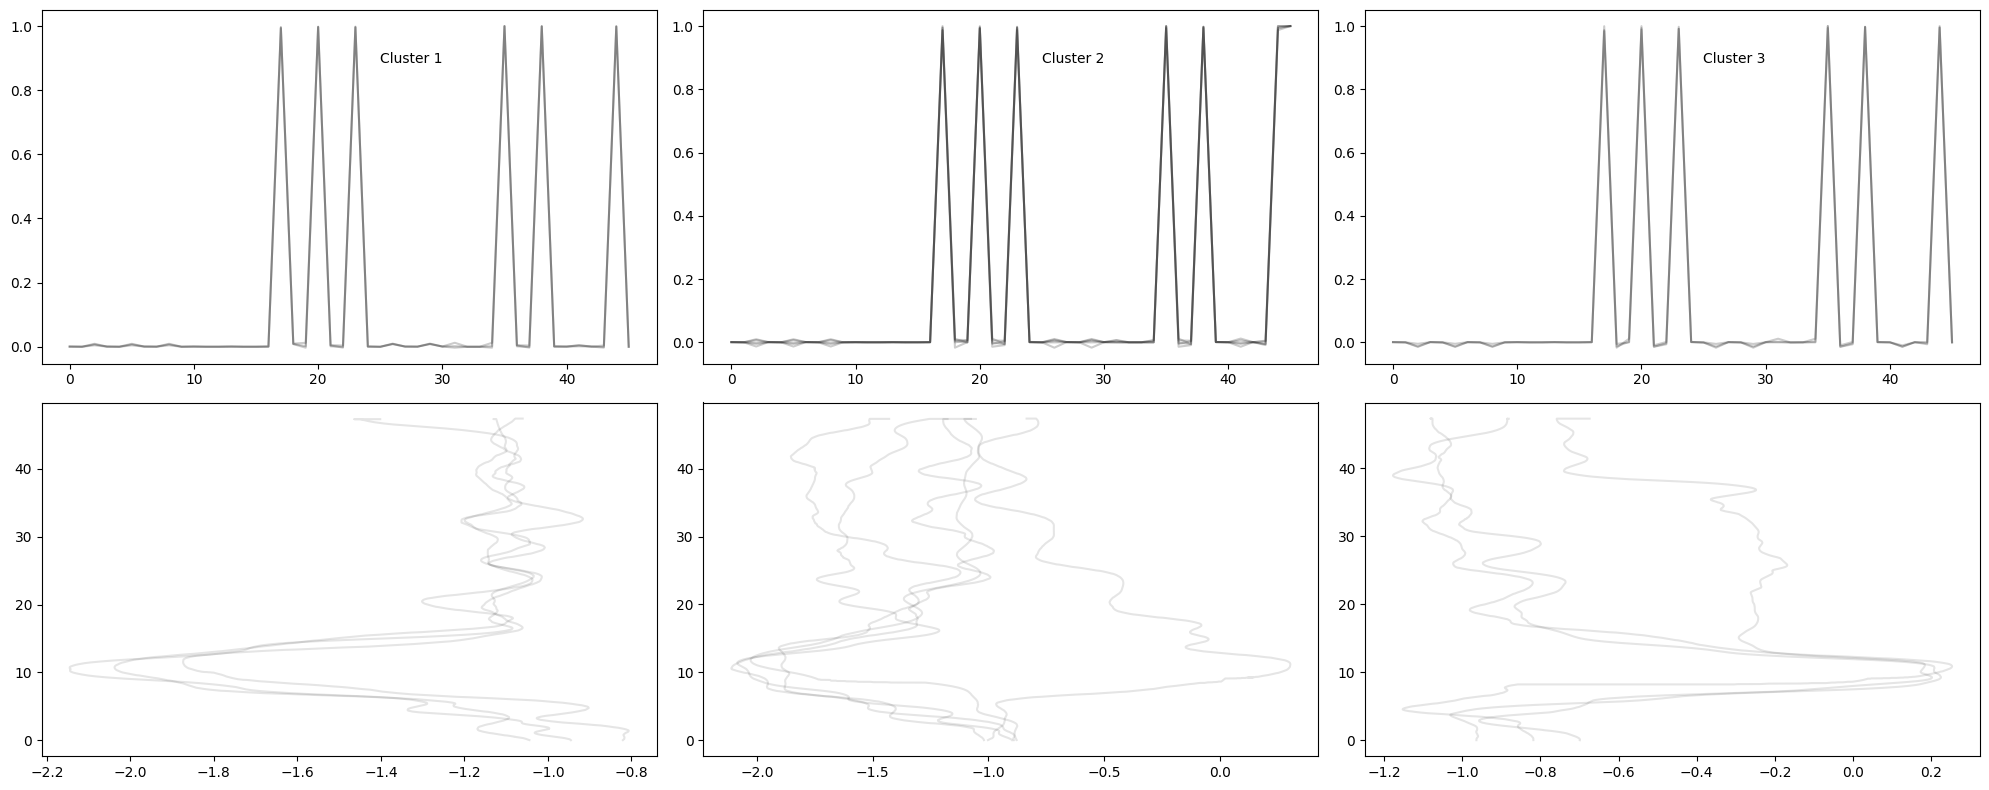

In [66]:
import matplotlib.pyplot as plt

def GraphClusterAndPath(numcluster, y_predit, ori_data, cluster_centers ):
    plt.figure(figsize =(20,8))
    for ci in range(numcluster):
        
        plt.subplot(2, numcluster, ci + 1)
        for xx in X_train[y_predit == ci]:
            plt.plot(xx.ravel(), "k-", alpha=.2)
        if(len(cluster_centers) > 0):
            plt.plot(cluster_centers[ci], "r-")
        plt.text(0.55, 0.85,'Cluster %d' % (ci + 1),
                transform=plt.gca().transAxes)

    for ci in range(numcluster):
        plt.subplot(2, numcluster, ci + 1+numcluster)
        filter = y_predit == ci
        for fi in range(len(filter)):
            if(filter[fi]):
                x = list(map(lambda coord: coord[0][0], ori_data[fi]))
                y = list(map(lambda coord: coord[0][2], ori_data[fi]))
                plt.plot(x,y, "k-", alpha=.1)

    
    plt.tight_layout()
    plt.show()


#print(pos_data)
GraphClusterAndPath(numcluster, y_predit, pos_data, cluster_centers)

In [69]:

def GraphPath(user_cluster, df,skipframe = -1):
    colors =[ "green", "blue", "DarkSlateGrey","MediumPurple","LightSkyBlue", "yellow", "purple","Brown", "Cyan"]
    colors +=['magenta', 'olive', 'teal', 'navy', 'maroon', 'aqua', 'lime', 'silver', 'fuchsia'] 
    fig = go.Figure()
    for ci in range(-1, numcluster):
            
        ufilter = user_cluster == ci
        colorIdx = 0
        numUser =  len(user_cluster[user_cluster == ci])
        #print(f"ci{ci},numUser ={numUser}, ufilter{ufilter} ")
        for fi in range(len(ufilter)): 
            
            if(not ufilter[fi]): #if it is not same cluster skip current user
                continue

            colorIdx +=1
            colorOpa = 0.01 + colorIdx/numUser
            colorOpa = 1 if colorOpa > 1  else colorOpa
            
            #get user id 
            userID = df['userID'][fi]

            filterDf = df[(df['userID'] == userID)]
            #print(userID)
            walkPath = filterDf['plyr_pos'].values[0]
            if(skipframe != -1):
                walkPath = walkPath[::skipframe]

            #distance, velocities, acceleration = CalDistVelAcc(walkPath, skipframe)

            traceName = f'user{str(userID)}_cluser{ci}' if ci >=0 else f'user{str(userID)}_no clusterGroup'
            
            def GraphWalkPath(walkPath):
                

                x_coords = list(map(lambda pos: pos[0], walkPath))
                z_coords = list(map(lambda pos: pos[2], walkPath))
                colors_name = np.arange(0, len(x_coords))
                trace = go.Scatter(
                    x =  x_coords,
                    y =  z_coords,
                    name =  f'{traceName}',
                    legendgroup= f"cluser{ci}",
                    #all lines in a group has same color
                    marker = dict(size=5, color =  colors[ci] if ci >=0 else colors[len(colors)-1]),
                    # each line has different color
                    #marker = dict(size=5, color = colors_name, colorscale='Viridis'),
                    opacity=colorOpa,
                )
                return trace
            def GraphAccDist(distance):
                trace = go.Scatter(
                x = [ i for i in range(len(distance)) ],
                y =  distance,
                name =  f'{traceName}_dist',
                legendgroup=f"cluser{ci}",
                marker=dict(size=5, color = colors[ci]),
                )
                return trace
            def GraphAcceleration(acceleration):
                trace = go.Scatter(
                    x = [ i for i in range(len(acceleration)) ],
                    y =  acceleration,
                    name =  f'{traceName}_acc',
                    legendgroup=f"cluser{ci}",
                    marker=dict(size=5, colorscale = 'Picnic'),
                )
                return trace
            def GraphVelocity(velocities):
                trace = go.Scatter(
                    x = [ i for i in range(len(velocities)) ],
                    y =  velocities,
                    name =  f'{traceName}_vel',
                    legendgroup=f"cluser{ci}",
                    marker=dict(size=5, color = colors[ci]),
                )
                return trace
            
            trace = GraphWalkPath(walkPath)
            
            #trace = GraphVelocity(velocities)
            fig.add_trace(trace)
    fig.show()


GraphPath(y_predit, dataset, frameToSkip)

In [68]:
def GraphFeatureRelationship(df, numcluster,featureNames):
    colors =[ "green", "blue", "rgb(165,42,42)","rgb(147, 112, 219)","rgb(135, 206, 250)", "yellow", "purple","DarkSlateGrey", "Cyan"]
    colors +=['magenta', 'olive', 'teal', 'navy', 'maroon', 'aqua', 'lime', 'silver', 'fuchsia'] 
    fig = go.Figure()
    
    tempdf = None
    x_feature = featureNames[0]
    y_feature = featureNames[1]
    z_feature = featureNames[2]
    for ci in range(numcluster): 

        filterDf = df[(df['y_predit'] == ci)]
        x_values = np.array(filterDf[x_feature].values) 
        y_values = np.array(filterDf[y_feature].values) 
        z_values = np.array(filterDf[z_feature].values) 

        trace = go.Scatter3d(
            x =  x_values,
            y =  y_values,
            z = z_values,
            name =  f"cluser{ci}",
            mode='markers',
            legendgroup= f"cluser{ci}",
            marker = dict(size=8, color =  colors[ci] if ci >=0 else colors[len(colors)-1]),
        )
        print(colors[ci])
        fig.add_trace(trace)

        # mean_trace = go.Scatter(
        #     x=[ f'cluser{ci}_mean'],
        #     y=[colValue.mean()],
        #     mode='markers',
        #     marker=dict(size=12, color='red'),
        #     legendgroup= f"cluser{ci}",
        #     name=f'cluser{ci}_mean'
        # )
        # fig.add_trace(mean_trace)

    layout = go.Layout(title= f"{x_feature} vs {y_feature} vs {z_feature}" , 
    scene=dict(
            xaxis=dict(title=x_feature),
            yaxis=dict(title=y_feature),
            zaxis=dict(title=z_feature),
        ))
    fig.update_layout(layout)
    fig.show()

dataset['y_predit'] = y_predit

#featureName = ['Button']
#featureName = ['GameplayResult','GameplayDur', 'DifficultyRating']  #'GameplayResult'#'FunRating'#'GameplayDur' #'DifficultyRating'
GraphFeatureRelationship(dataset, numcluster, featureName)

IndexError: list index out of range

In [67]:
def GraphColumn(df, numcluster,featureName):
    colors =[ "green", "blue", "DarkSlateGrey","MediumPurple","LightSkyBlue", "yellow", "purple","Brown", "Cyan"]
    colors +=['magenta', 'olive', 'teal', 'navy', 'maroon', 'aqua', 'lime', 'silver', 'fuchsia'] 
    fig = go.Figure()
    

    for ci in range(numcluster): 

        filterDf = df[(df['y_predit'] == ci)]
        colValue = np.array(filterDf[featureName].values) 
        

        x_names = [ f'u{userID}'  for userID in filterDf['userID']]  
        traceName = [f'cluser{ci}' if ci >=0 else f'no clusterGroup' for userID in filterDf['userID']] 
        
        trace = go.Scatter(
            x =  x_names,
            y =  colValue,
            name =  f"cluser{ci}",
            legendgroup= f"cluser{ci}",
           
            marker = dict(size=5, color =  colors[ci] if ci >=0 else colors[len(colors)-1]),
        )
        fig.add_trace(trace)

        mean_trace = go.Scatter(
            x=[ f'cluser{ci}_mean'],
            y=[colValue.mean()],
            mode='markers',
            marker=dict(size=12, color='red'),
            legendgroup= f"cluser{ci}",
            name=f'cluser{ci}_mean'
        )
        fig.add_trace(mean_trace)

    layout = go.Layout(title= featureName , xaxis=dict(title='Users'), yaxis=dict(title= featureName))
    fig.update_layout(layout)
    fig.show()

dataset['y_predit'] = y_predit

featureName = 'Button'
#featureName = 'GameplayDur'  #'GameplayResult'#'FunRating'#'GameplayDur' #'DifficultyRating'
GraphColumn(dataset, numcluster, featureName)